# **1. Import Library**
Pada tahap ini, perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
!pip install nltk
!pip install nlpaug
!pip install Sastrawi
!pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import wordninja
import random
import joblib

import string, re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import matplotlib.pyplot as plt
from wordcloud import WordCloud

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mahda\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mahda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **2. Memuat Dataset dari Hasil Scrapping**
Memuat dataset hasil scrapping dari file CSV ke dalam variabel DataFrame.

In [3]:
# Load data
datafile = pd.read_csv('ulasanDPS.csv')

# Menampilkan 5 data teratas
print(datafile.head())

                                              ulasan  rating sentiment
0  Kepada pihak terkait, saya gagal mengajukan pe...       3    Netral
1  udah bikin akun , tapi gak bisa login karna em...       2   Negatif
2  Saat membuat pengaduan aplikasi tiba2 crash da...       1   Negatif
3  menu Daftar masih eror, Menu Live CCTV masih E...       2   Negatif
4  1 bintang dulu ya. Tiang sudah dari kemarin do...       1   Negatif


In [4]:
# Menampilkan 5 data terakhir
print(datafile.tail())

                    ulasan  rating sentiment
152                 Mantap       5   Positif
153                    top       5   Positif
154               Mantapp💪       5   Positif
155  Inspirasi banget😍😍😍😍😍       5   Positif
156        Sangat membantu       5   Positif


In [5]:
# Menampilkan tipe data dan info memori
print(datafile.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ulasan     157 non-null    object
 1   rating     157 non-null    int64 
 2   sentiment  157 non-null    object
dtypes: int64(1), object(2)
memory usage: 3.8+ KB
None


In [6]:
# Mengecek jumlah data kosong di setiap kolom
print(datafile.isnull().sum()) 

ulasan       0
rating       0
sentiment    0
dtype: int64


In [7]:
# Cek distribusi sentiment
datafile['sentiment'].value_counts()

sentiment
Positif    90
Negatif    59
Netral      8
Name: count, dtype: int64

# **3. Preprocessing Teks**
Tahap Preprocessing bertujuan untuk membersihkan dataset agar dapat digunakan untuk melatih model machine learning.

In [8]:
datafile['lowercase'] = datafile['ulasan'].str.lower()

casefolding = pd.DataFrame(datafile['lowercase'])
print(casefolding)

                                             lowercase
0    kepada pihak terkait, saya gagal mengajukan pe...
1    udah bikin akun , tapi gak bisa login karna em...
2    saat membuat pengaduan aplikasi tiba2 crash da...
3    menu daftar masih eror, menu live cctv masih e...
4    1 bintang dulu ya. tiang sudah dari kemarin do...
..                                                 ...
152                                             mantap
153                                                top
154                                           mantapp💪
155                              inspirasi banget😍😍😍😍😍
156                                    sangat membantu

[157 rows x 1 columns]


In [9]:
def remove_punctuations(text):

    # ganti tanda hubung jadi spasi
    text = text.replace('-', ' ')
    text = text.replace('/', ' ')
    text = text.replace('.', ' ')
    text = text.replace(',', ' ')

    # hapus mention
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)

    # hapus hashtag
    text = re.sub(r'#', '', text)

    # hapus RT
    text = re.sub(r'\bRT\b', '', text)

    # hapus link
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus emoji
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002700-\U000027BF"
        "]+",
        flags=re.UNICODE
    )

    text = emoji_pattern.sub(r'', text)

    # hapus newline
    text = text.replace('\n', ' ')

    # hapus punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # hilangkan huruf berulang berlebihan
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# apply ke dataframe
datafile['cleanpunct'] = datafile['lowercase'].apply(remove_punctuations)
print(datafile['cleanpunct'].head())
datafile[['lowercase', 'cleanpunct']].to_csv('Remover_DPS.csv', index=False)

0    kepada pihak terkait saya gagal mengajukan pen...
1    udah bikin akun tapi gak bisa login karna emai...
2    saat membuat pengaduan aplikasi tiba crash dan...
3    menu daftar masih eror menu live cctv masih er...
4    bintang dulu ya tiang sudah dari kemarin downl...
Name: cleanpunct, dtype: object


In [10]:
custom_stopwords = {'ya', 'nya', 'deh', 'sih', 'kok', 'dong', 'lah', 'kan', 'nyak', 'bsa', 'deh', 'nah', 'hm', 'je', 'adu', 'kah'}

def tokenizingText(text):
    tokens = word_tokenize(text)
    filtered = [t for t in tokens if t.lower() not in custom_stopwords]
    return filtered

datafile['tokens'] = datafile['cleanpunct'].apply(tokenizingText)

tokenize = pd.DataFrame(datafile['tokens'])
print(tokenize)

                                                tokens
0    [kepada, pihak, terkait, saya, gagal, mengajuk...
1    [udah, bikin, akun, tapi, gak, bisa, login, ka...
2    [saat, membuat, pengaduan, aplikasi, tiba, cra...
3    [menu, daftar, masih, eror, menu, live, cctv, ...
4    [bintang, dulu, tiang, sudah, dari, kemarin, d...
..                                                 ...
152                                           [mantap]
153                                              [top]
154                                          [mantapp]
155                                [inspirasi, banget]
156                                 [sangat, membantu]

[157 rows x 1 columns]


In [11]:
normalized_word = pd.read_csv('normalisasi_variasi.csv')

normalized_word_dict = {}
for index, row in normalized_word.iterrows():
   if row['kata_tidak_baku'] not in normalized_word_dict:
        normalized_word_dict[row['kata_tidak_baku']] = row['kata_baku']
        
def normalized(document):
    return [normalized_word_dict[term] if term in normalized_word_dict else term for term in document]

datafile['normalization'] = datafile['tokens'].apply(normalized)
normalization = pd.DataFrame(datafile['normalization'])
print(normalization)

                                         normalization
0    [kepada, pihak, terkait, saya, gagal, mengajuk...
1    [sudah, bikin, akun, tapi, tidak, bisa, login,...
2    [saat, membuat, pengaduan, aplikasi, tiba, cra...
3    [menu, daftar, masih, error, menu, live, cctv,...
4    [bintang, dulu, saya, sudah, dari, kemarin, do...
..                                                 ...
152                                           [mantap]
153                                              [top]
154                                           [mantap]
155                                [inspirasi, banget]
156                                 [sangat, membantu]

[157 rows x 1 columns]


In [12]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
   stems = [stemmer.stem(word) for word in tokens]
   return ' '.join(stems)

datafile['stemming'] = datafile['normalization'].apply(stemming)
stemming = pd.DataFrame(datafile['stemming'])
print(stemming)

                                              stemming
0    kepada pihak kait saya gagal aju adu apakah ad...
1    sudah bikin akun tapi tidak bisa login karena ...
2    saat buat adu aplikasi tiba crash dan logout c...
3    menu daftar masih error menu live cctv masih e...
4    bintang dulu saya sudah dari kemarin download ...
..                                                 ...
152                                             mantap
153                                                top
154                                             mantap
155                                   inspirasi banget
156                                       sangat bantu

[157 rows x 1 columns]


In [13]:
def clean_stopwords(tokens):
    stopword_id = set(stopwords.words('indonesian'))
    stopword_eng = set(stopwords.words('english'))

    # gabungkan
    all_stopwords = stopword_id.union(stopword_eng)

    # kata penting sentiment jangan dihapus
    important_words = {
        'baik',
        'bukan',
        'belum',
        'kurang',
        'lebih',
        'sangat',
        'gagal',
        'error',
        'bagus',
        'buruk',
        'cepat',
        'lambat',
        'susah',
        'mudah',
        'tolong',
        'login',
        'daftar',
        'registrasi',
        'aju',
        'adu',
        'keluh',
        'aplikasi',
        'mantap',
        'keren',
        'bantu',
        'manfaat',
        'sulit',
        'hasil',
        'parah',
        'bantu'
    }

    # keluarkan kata penting dari stopword
    all_stopwords = all_stopwords - important_words

    # filtering
    text = [
        word for word in tokens
        if word not in all_stopwords
    ]

    return text
    
datafile['tokens'] = datafile['stemming'].apply(word_tokenize)

datafile['stopword'] = datafile['tokens'].apply(clean_stopwords)

datafile['stopword_str'] = datafile['stopword'].apply(lambda x: ' '.join(x))

stopword = pd.DataFrame(datafile['stopword_str'])
print(stopword)

datafile[['lowercase', 'cleanpunct', 'tokens', 'normalization', 'stemming', 'stopword_str', 'rating', 'sentiment']].to_csv('preprocessing_DPS.csv', index=False)
print("File berhasil disimpan.")

                                          stopword_str
0    kait gagal aju adu error bug aplikasi aju munc...
1    bikin akun login email daftar sistem gilir daf...
2    adu aplikasi crash logout adu ulang mohon semp...
3    menu daftar error menu live cctv error menu in...
4    bintang kemarin download registrasi salah coba...
..                                                 ...
152                                             mantap
153                                                top
154                                             mantap
155                                   inspirasi banget
156                                       sangat bantu

[157 rows x 1 columns]
File berhasil disimpan.


In [14]:
# Baca dataset hasil labeling
final_df = pd.read_csv('preprocessing_DPS.csv')

selected_columns = final_df[['stopword_str', 'rating', 'sentiment']]

# Hapus baris yang nilai 'stopword_str' kosong atau NaN
selected_columns = selected_columns.dropna(subset=['stopword_str'])

selected_columns = selected_columns[selected_columns['stopword_str'].str.strip() != ""]

# Cek hasil
print(selected_columns.head())
print(selected_columns['sentiment'].value_counts())

selected_columns.to_csv('komentar_DPS.csv', index=False)

                                        stopword_str  rating sentiment
0  kait gagal aju adu error bug aplikasi aju munc...       3    Netral
1  bikin akun login email daftar sistem gilir daf...       2   Negatif
2  adu aplikasi crash logout adu ulang mohon semp...       1   Negatif
3  menu daftar error menu live cctv error menu in...       2   Negatif
4  bintang kemarin download registrasi salah coba...       1   Negatif
sentiment
Positif    85
Negatif    59
Netral      8
Name: count, dtype: int64


# **4. Augmentasi Data**
Tahap augmentasi data menggunakan sinonim bertujuan untuk balance dataset menjadikan jumlah data dengan sentimen positif dan negatif seimbang.

In [15]:
def load_kamus(csv_path):
    datafile = pd.read_csv(csv_path)
    datafile.columns = datafile.columns.str.strip().str.lower()
    kamus = {}
    for _, row in datafile.iterrows():
        base = row['kata'].strip().lower()
        kamus[base] = []
        for col in ['sinonim1', 'sinonim2', 'sinonim3']:
            if pd.notna(row[col]):
                kamus[base].append(row[col].strip().lower())
    return kamus


def aug_sinonim_kalimat(text, kamus, n=3):
    words = text.lower().split()
    new_words = words.copy()

    kandidat = [w for w in words if w in kamus and kamus[w]]
    if not kandidat:
        return text

    random.shuffle(kandidat)
    kandidat = kandidat[:min(n, len(kandidat))]

    for word in kandidat:
        if kamus[word]:
            synonym = random.choice(kamus[word])
            new_words = [synonym if w == word else w for w in new_words]

    return ' '.join(new_words)


def augment_dataset(input_csv, kamus_csv, output_csv):
    datafile = pd.read_csv(input_csv)
    kamus = load_kamus(kamus_csv)

    class_counts = datafile['sentiment'].value_counts()
    target_per_class = class_counts.max()
    print(f"Target augmentasi per kelas: {target_per_class}")
    print(f"Distribusi awal:\n{class_counts}\n")

    augmented_only = []

    for label in class_counts.index:
        label_df = datafile[datafile['sentiment'] == label]
        current_count = len(label_df)
        needed = target_per_class - current_count

        print(f"⏳ Sentimen: {label} | Saat ini: {current_count} | Dibutuhkan: {needed}")

        if needed <= 0:
            continue

        success_count = 0
        attempts = 0
        max_attempts = needed * 5

        while success_count < needed and attempts < max_attempts:
            row = label_df.sample(n=1, replace=True).iloc[0]
            original_text = row['stopword_str']
            augmented_text = aug_sinonim_kalimat(original_text, kamus, n=3)

            if augmented_text != original_text:
                augmented_only.append({
                    'stopword_str': augmented_text,
                    'sentiment': row['sentiment']
                })
                success_count += 1
            attempts += 1

        print(f"Ditambahkan untuk '{label}': {success_count} kalimat\n")

    # Simpan hasil augmentasi
    if augmented_only:
        augmented_df = pd.DataFrame(augmented_only)
        augmented_df.to_csv(output_csv, index=False)
        print(f"Augmentasi selesai. Total {len(augmented_only)} data ditambahkan ke '{output_csv}'")
    else:
        print("Tidak ada data yang berhasil diaugmentasi.")

if __name__ == "__main__":
    augment_dataset(
        input_csv='komentar_DPS.csv',
        kamus_csv='kamus_sinonim.csv',
        output_csv='augmentedDPS.csv'
    )

Target augmentasi per kelas: 85
Distribusi awal:
sentiment
Positif    85
Negatif    59
Netral      8
Name: count, dtype: int64

⏳ Sentimen: Positif | Saat ini: 85 | Dibutuhkan: 0
⏳ Sentimen: Negatif | Saat ini: 59 | Dibutuhkan: 26
Ditambahkan untuk 'Negatif': 26 kalimat

⏳ Sentimen: Netral | Saat ini: 8 | Dibutuhkan: 77
Ditambahkan untuk 'Netral': 77 kalimat

Augmentasi selesai. Total 103 data ditambahkan ke 'augmentedDPS.csv'


In [16]:
datafile1 = pd.read_csv('augmentedDPS.csv')
datafile2 = pd.read_csv('komentar_DPS.csv')

final_datafile = pd.concat([datafile1, datafile2], ignore_index=True)

# hapus kolom rating
final_datafile = final_datafile.drop(columns=['rating'])

final_datafile.to_csv('dataset_DPS.csv', index=False)
print("File berhasil disimpan.")

File berhasil disimpan.


In [17]:
print("Distribusi data:\n", final_datafile['sentiment'].value_counts())

Distribusi data:
 sentiment
Negatif    85
Netral     85
Positif    85
Name: count, dtype: int64


# **5. Data Splitting**
Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [18]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

datafile = pd.read_csv("dataset_DPS.csv")

# Pisahkan fitur dan label
X = datafile['stopword_str'].astype(str)  
y = datafile['sentiment']                  

# Split 80% latih dan 20% uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED, shuffle=True)

train_df = pd.DataFrame({'stopword_str': X_train, 'sentiment': y_train})
test_df = pd.DataFrame({'stopword_str': X_test, 'sentiment': y_test})

train_df.to_csv('data_train_DPS.csv', index=False)
test_df.to_csv('data_test_DPS.csv', index=False)

print("File data_train.csv dan data_test.csv berhasil disimpan.")

File data_train.csv dan data_test.csv berhasil disimpan.


In [19]:
print("Distribusi data latih:\n", y_train.value_counts())
print("Distribusi data uji:\n", y_test.value_counts())

Distribusi data latih:
 sentiment
Negatif    68
Netral     68
Positif    68
Name: count, dtype: int64
Distribusi data uji:
 sentiment
Negatif    17
Positif    17
Netral     17
Name: count, dtype: int64


# **6. Feature Extraction**
Tahap TF-IDF bertujuan untuk mengubah dataset kedalam  bentuk keyword bernilai numerik.

In [20]:
#Load Data
train_df = pd.read_csv("data_train_DPS.csv")
test_df = pd.read_csv("data_test_DPS.csv")

X_train_text = train_df['stopword_str'].astype(str)
y_train = train_df['sentiment']

X_test_text = test_df['stopword_str'].astype(str)
y_test = test_df['sentiment']

tfidf = TfidfVectorizer(
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 1)  # Unigram
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

feature_names = tfidf.get_feature_names_out()

def extract_top_keywords(doc_vector, feature_names, top_n=10):
    indices = np.argsort(doc_vector)[::-1][:top_n]
    return [feature_names[i] for i in indices]

dense_tfidf = X_train_tfidf.toarray()
all_keywords = [
    extract_top_keywords(vec, feature_names)
    for vec in dense_tfidf
]

df_keywords = pd.DataFrame({
    'stopword_str': X_train_text.values,
    'keywords': all_keywords,
})
df_keywords.to_csv('hasil_keywords_DPS.csv', index=False)

mean_tfidf = X_train_tfidf.mean(axis=0).A1
tfidf_scores = pd.DataFrame({
    'kata': feature_names,
    'skor_DPS': mean_tfidf
}).sort_values('skor_DPS', ascending=False)

print("20 Kata dengan skor TF-IDF tertinggi:")
print(tfidf_scores.head(20))

# Simpan vectorizer
joblib.dump(tfidf, "vectorizer_tfidf_DPS.joblib")

20 Kata dengan skor TF-IDF tertinggi:
         kata  skor_DPS
10   aplikasi  0.085931
22       buka  0.069584
13       baik  0.061038
1         adu  0.060722
3       akses  0.056119
78     lampir  0.052042
42       file  0.052042
39      error  0.049741
35   denpasar  0.046382
90     mantap  0.043283
32     daftar  0.043090
2         aju  0.042745
130    sangat  0.041488
86      login  0.040150
12      bagus  0.036236
99      mohon  0.034718
134    server  0.033572
44       foto  0.033332
62       kali  0.030039
89    manfaat  0.029394


['vectorizer_tfidf_DPS.joblib']

# **7. Membangun Model Klasifikasi**
Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah tahapannya.
1. Menggunakan algoritma klasifikasi yaitu Logistic Regression, Naive Bayes, Random Forest, SVM.
2. Latih model menggunakan data yang sudah dipisah.


MODEL : Logistic Regression

HASIL CROSS VALIDATION
Fold 1: 0.9512
Fold 2: 0.9024
Fold 3: 0.9512
Fold 4: 0.9512
Fold 5: 0.8250

Rata-rata CV Accuracy : 0.9162
Std CV Accuracy       : 0.0494

HASIL TRAINING
Training Accuracy : 0.9510

HASIL TESTING
Testing Accuracy : 0.9412

ANALISIS MODEL
Gap Train-Test : 0.0098
Indikasi : GOOD FIT

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Negatif       0.94      0.88      0.91        17
      Netral       1.00      1.00      1.00        17
     Positif       0.89      0.94      0.91        17

    accuracy                           0.94        51
   macro avg       0.94      0.94      0.94        51
weighted avg       0.94      0.94      0.94        51



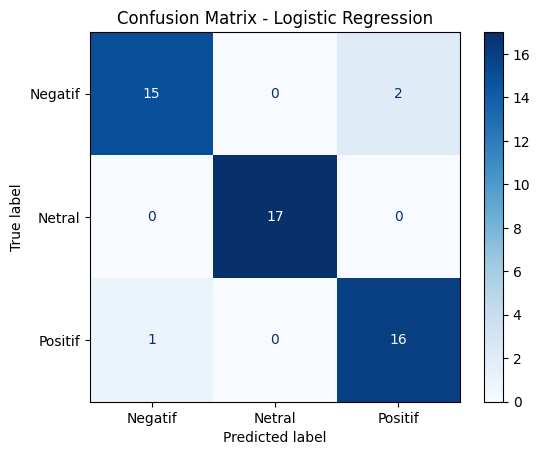

Model berhasil disimpan: model_logistic_regression_DPS.joblib

MODEL : Naive Bayes

HASIL CROSS VALIDATION
Fold 1: 0.9268
Fold 2: 0.8780
Fold 3: 0.9268
Fold 4: 0.8293
Fold 5: 0.8750

Rata-rata CV Accuracy : 0.8872
Std CV Accuracy       : 0.0367

HASIL TRAINING
Training Accuracy : 0.9363

HASIL TESTING
Testing Accuracy : 0.9412

ANALISIS MODEL
Gap Train-Test : -0.0049
Indikasi : GOOD FIT

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Negatif       1.00      0.88      0.94        17
      Netral       0.89      1.00      0.94        17
     Positif       0.94      0.94      0.94        17

    accuracy                           0.94        51
   macro avg       0.95      0.94      0.94        51
weighted avg       0.95      0.94      0.94        51



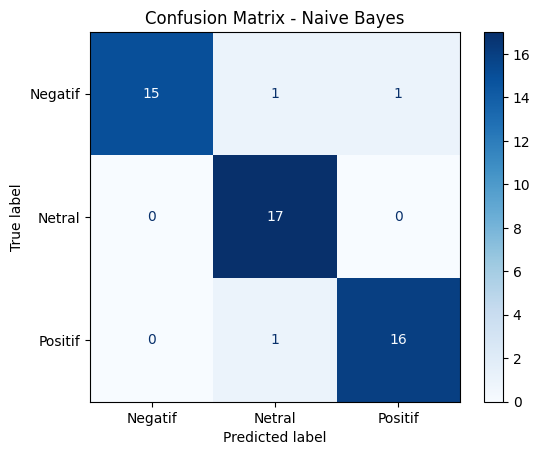

Model berhasil disimpan: model_naive_bayes_DPS.joblib

MODEL : Random Forest

HASIL CROSS VALIDATION
Fold 1: 0.9512
Fold 2: 0.9024
Fold 3: 0.9268
Fold 4: 0.9512
Fold 5: 0.8000

Rata-rata CV Accuracy : 0.9063
Std CV Accuracy       : 0.0562

HASIL TRAINING
Training Accuracy : 0.9951

HASIL TESTING
Testing Accuracy : 0.9020

ANALISIS MODEL
Gap Train-Test : 0.0931
Indikasi : GOOD FIT

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Negatif       0.93      0.76      0.84        17
      Netral       1.00      1.00      1.00        17
     Positif       0.80      0.94      0.86        17

    accuracy                           0.90        51
   macro avg       0.91      0.90      0.90        51
weighted avg       0.91      0.90      0.90        51



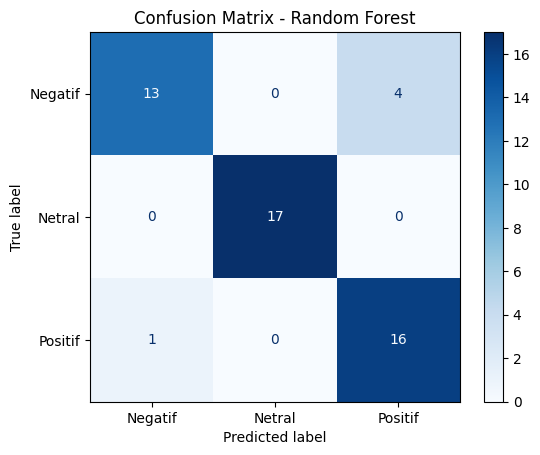

Model berhasil disimpan: model_random_forest_DPS.joblib

MODEL : SVM

HASIL CROSS VALIDATION
Fold 1: 0.9268
Fold 2: 0.9268
Fold 3: 0.9268
Fold 4: 0.9024
Fold 5: 0.8500

Rata-rata CV Accuracy : 0.9066
Std CV Accuracy       : 0.0298

HASIL TRAINING
Training Accuracy : 0.9657

HASIL TESTING
Testing Accuracy : 0.9412

ANALISIS MODEL
Gap Train-Test : 0.0245
Indikasi : GOOD FIT

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Negatif       0.94      0.88      0.91        17
      Netral       1.00      1.00      1.00        17
     Positif       0.89      0.94      0.91        17

    accuracy                           0.94        51
   macro avg       0.94      0.94      0.94        51
weighted avg       0.94      0.94      0.94        51



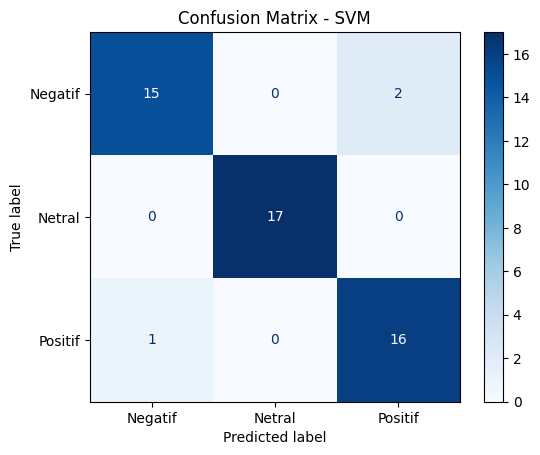

Model berhasil disimpan: model_svm_DPS.joblib


In [21]:
# Load data
df_train = pd.read_csv("data_train_DPS.csv")
df_test = pd.read_csv("data_test_DPS.csv")

X_train_text = df_train['stopword_str']
y_train = df_train['sentiment']

X_test_text = df_test['stopword_str']
y_test = df_test['sentiment']

# Encode label ke angka
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# simpan label encoder
joblib.dump(le, "label_encoder_DPS.joblib")

# Load TF-IDF vectorizer
tfidf = joblib.load("vectorizer_tfidf_DPS.joblib")

# transform text
X_train = tfidf.transform(X_train_text)
X_test = tfidf.transform(X_test_text)

# Daftar model
models = {
    "Logistic Regression": LogisticRegression(
        C=0.1,
        penalty='l2',
        solver='saga',
        max_iter=1000
    ),

    "Naive Bayes": MultinomialNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "SVM": SVC(
        kernel='linear',
        random_state=42
    )
}

# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Latih, evaluasi, dan simpan model
for name, model in models.items():
    print(f"\nMODEL : {name}")

    # Cross Validation
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train_enc,
        cv=skf,
        scoring='accuracy'
    )

    print("\nHASIL CROSS VALIDATION")
    for i, score in enumerate(cv_scores):
        print(f"Fold {i+1}: {score:.4f}")

    print(f"\nRata-rata CV Accuracy : {np.mean(cv_scores):.4f}")
    print(f"Std CV Accuracy       : {np.std(cv_scores):.4f}")


    # Train model
    model.fit(X_train, y_train_enc)
    
    y_train_pred_enc = model.predict(X_train)
    y_train_pred = le.inverse_transform(y_train_pred_enc)

    train_acc = accuracy_score(y_train, y_train_pred)

    print("\nHASIL TRAINING")
    print(f"Training Accuracy : {train_acc:.4f}")

    y_test_pred_enc = model.predict(X_test)
    y_test_pred = le.inverse_transform(y_test_pred_enc)

    test_acc = accuracy_score(y_test, y_test_pred)

    print("\nHASIL TESTING")
    print(f"Testing Accuracy : {test_acc:.4f}")

    gap = train_acc - test_acc

    print("\nANALISIS MODEL")
    print(f"Gap Train-Test : {gap:.4f}")

    if gap > 0.10:
        print("Indikasi : OVERFITTING")

    elif train_acc < 0.70 and test_acc < 0.70:
        print("Indikasi : UNDERFITTING")

    else:
        print("Indikasi : GOOD FIT")

    print("\nCLASSIFICATION REPORT")
    print(classification_report(y_test, y_test_pred))
    
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_test_pred,
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.grid(False)
    plt.show()

    filename = f"model_{name.lower().replace(' ', '_')}_DPS.joblib"

    joblib.dump(model, filename)

    print(f"Model berhasil disimpan: {filename}")

# **8. Membangun WordCloud**
Setelah melatih model machine learning, selanjutnya dilakukan pengelompokan kata-kata yang sering muncul.

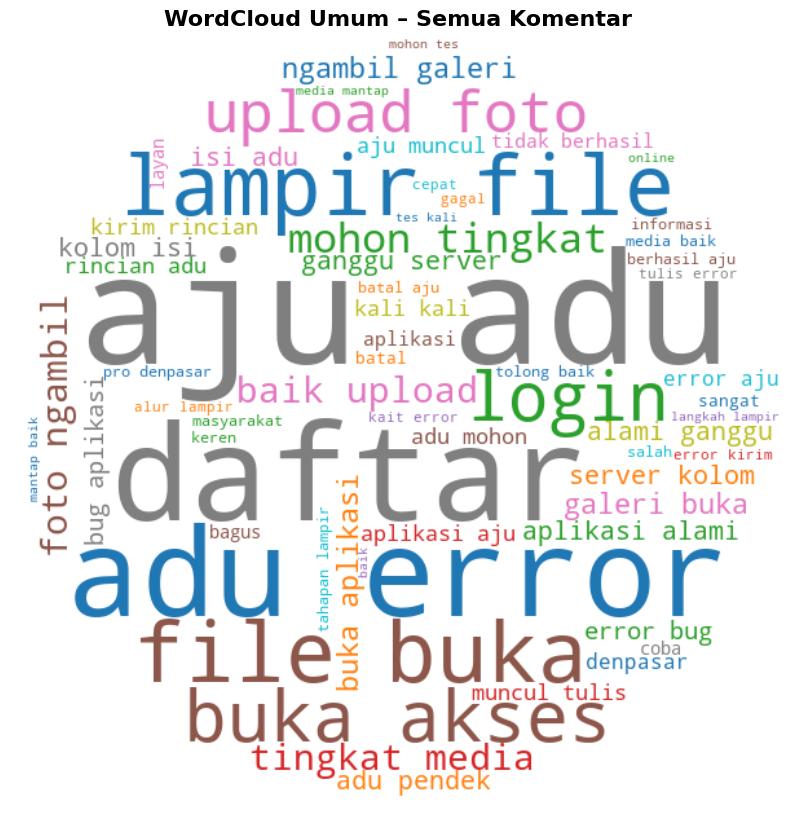

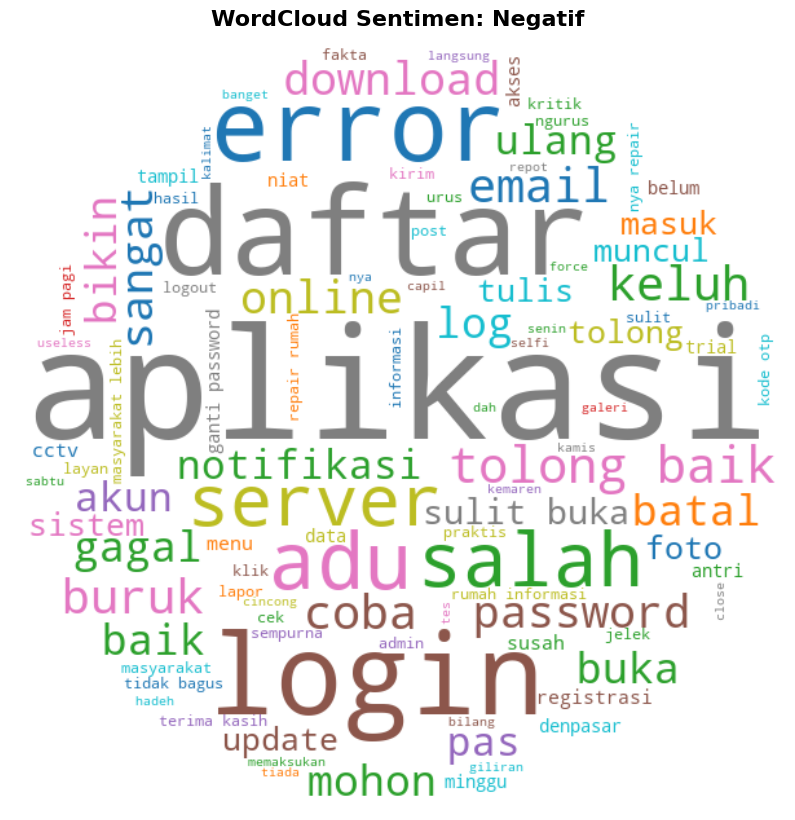

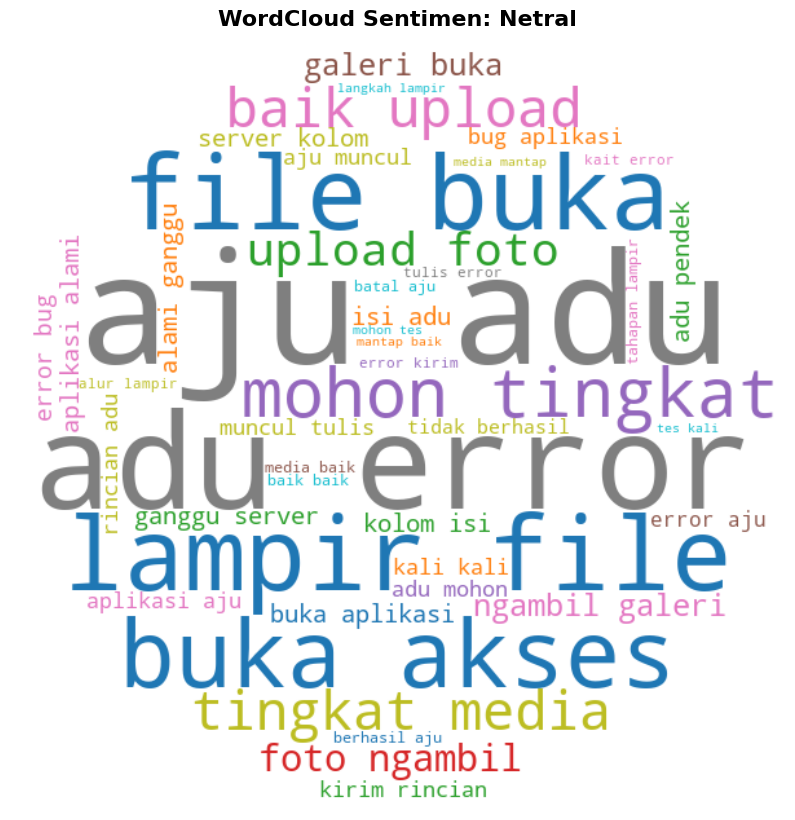

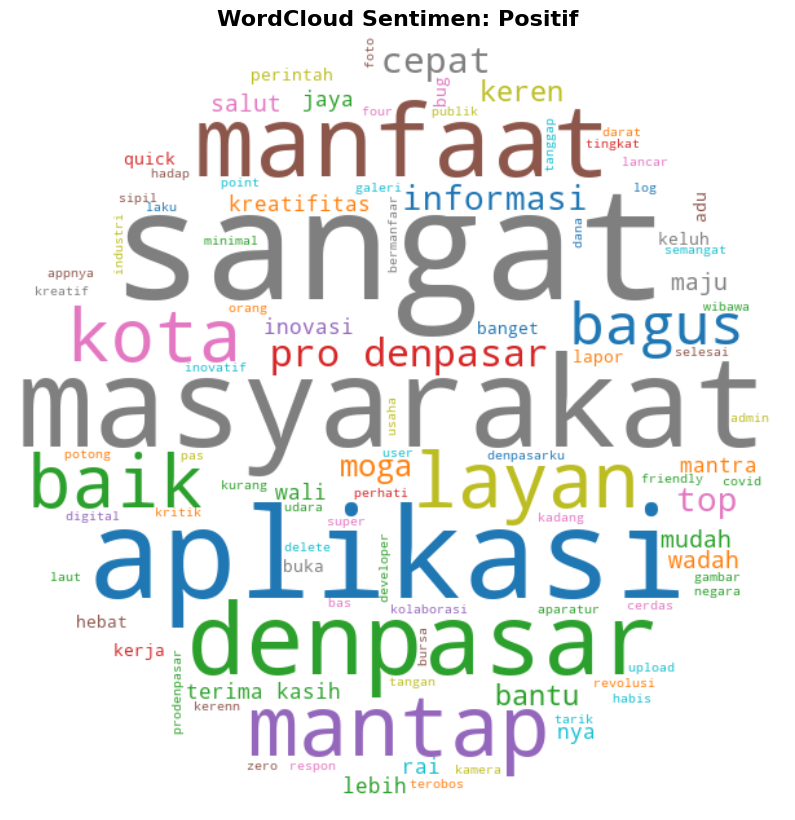

In [22]:
def create_circle_mask(diameter=600):
    "Membuat mask berbentuk lingkaran dengan ukuran diameter tertentu"
    x, y = np.ogrid[:diameter, :diameter]
    center = diameter // 2
    radius = diameter // 2
    mask = (x - center)**2 + (y - center)**2 > radius**2
    mask = 255 * mask.astype(int)
    return mask

def generate_wordcloud(text, title):
    circle_mask = create_circle_mask(600)

    wordcloud = WordCloud(
        width=200, height=200,
        background_color='white',
        colormap='tab10',
        max_words=100,
        prefer_horizontal=0.9,
        min_font_size=10,
        max_font_size=120,
        random_state=42,
        mask=circle_mask
    ).generate(text)

    plt.figure(figsize=(8, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=16, fontweight='bold')
    plt.tight_layout(pad=0)
    plt.show()

# WordCloud semua komentar (umum)
all_text = ' '.join(datafile['stopword_str'])
generate_wordcloud(all_text, "WordCloud Umum – Semua Komentar")

# WordCloud per sentimen (positif, negatif)
for label in datafile['sentiment'].unique():
    sentimen_text = ' '.join(datafile[datafile['sentiment'] == label]['stopword_str'])
    generate_wordcloud(sentimen_text, f"WordCloud Sentimen: {label.capitalize()}")

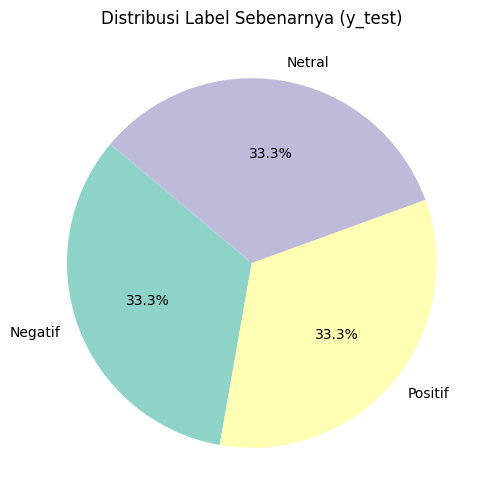

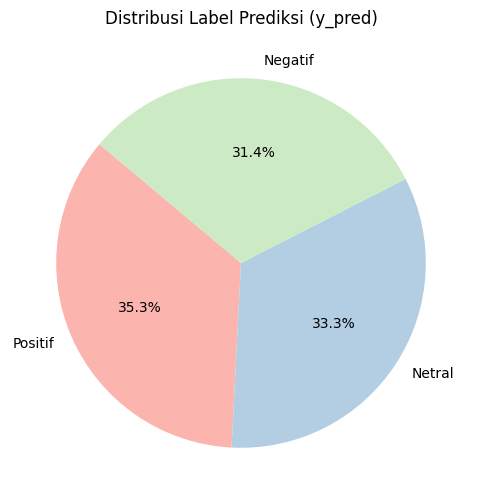

In [23]:
# Distribusi label sebenarnya (y_test)
plt.figure(figsize=(6, 6))
y_test.value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3.colors,
    labels=y_test.value_counts().index
)
plt.title("Distribusi Label Sebenarnya (y_test)")
plt.ylabel('')
plt.show()

# Distribusi label hasil prediksi (y_pred)
plt.figure(figsize=(6, 6))
pd.Series(y_test_pred).value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Pastel1.colors,
    labels=pd.Series(y_test_pred).value_counts().index
)
plt.title("Distribusi Label Prediksi (y_pred)")
plt.ylabel('')
plt.show()

In [24]:
emosi_lexicon = {
    "senang": [
        "terima kasih", "suksma", "mantap", "bagus", "baik", "puas", "makasih",
        "moga lancar", "nggih", "selamat", "hebat", "nyaman", "ideal", "makmur", "unggul",
    ],
    "sedih": [
        "sedih", "kecewa", "miris", "nyeri", "parah", "sayang", "capek", "buruk", "rusak",
        "banjir", "lubang", "bobol", "buntu", "kotor", "bahaya", "gelap", "begajulan", "tidak rata",
        "tidak nyaman", "tidak fungsi", "tidak profesional"
    ],
    "marah": [
        "ngapain", "aneh", "kenapa", "kok bisa", "gimana", "tidak tahu", "kenapa belum",
        "asal-asalan", "tidak sesuai", "salah", "tidak mempan", "komplain", "tidak adil", "parah", "jelek", "kurang"
    ],
    "optimis": [
        "optimis", "harap", "semoga", "astungkara", "yakin", "mudah-mudahan",
        "moga", "harap", "lanjut", "segera", "dalam tahap", "akan baik", "akan aspal",
        "akan diperbaiki", "masuk list", "masuk proyek", "teruskan", "ditindaklanjuti"
    ],
    "ragu-ragu": [
        "mungkin", "bingung", "gatau", "tidak tahu", "ragu", "entahlah", "kurang tahu",
        "belum pasti", "kayaknya", "seperti", "kalau", "kira-kira"
    ],
    "kritis": [
        "cek", "tolong", "kapan", "kenapa", "harap", "koordinasi", "perlu perhatian",
        "tolong atensi", "apakah", "harus", "bagaimana", "seharusnya", "kenapa tidak", "mohon",
    ]
}
joblib.dump(emosi_lexicon, "emosi_lexicon.joblib")

['emosi_lexicon.joblib']

In [27]:
# Load semua
vectorizer = joblib.load("vectorizer_tfidf_DPS.joblib")
model_sentimen = joblib.load("model_logistic_regression_DPS.joblib")
emosi_lexicon = joblib.load("emosi_lexicon.joblib")
le = joblib.load("label_encoder_DPS.joblib")

def predict_sentiment(text):
    text_clean = text.lower().strip()
    text_vector = vectorizer.transform([text_clean])
    pred_sentimen_enc = model_sentimen.predict(text_vector)[0]
    pred_sentimen = le.inverse_transform([pred_sentimen_enc])[0]  # ubah angka ke label asli
    pred_emosi = deteksi_emosi(text_clean)
    return pred_sentimen, pred_emosi

def deteksi_emosi(teks):
    for emosi, kata_kunci in emosi_lexicon.items():
        for kata in kata_kunci:
            if kata in teks:
                return emosi
    return "netral"

In [28]:
# Uji coba
text = "aplikasi jelek sekali lemot"
sentimen, emosi = predict_sentiment(text)
print("Teks:", text)
print("Sentimen:", sentimen)
print("Emosi:", emosi)

Teks: aplikasi jelek sekali lemot
Sentimen: Negatif
Emosi: marah
